Note to self from Fausto: use env pymc523

In [2]:
from scripts.data_functions import get_data, get_analysis_arrays, get_first_n_trials
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pymc as pm
import pytensor as pt
import xarray as xr
import arviz as az
import bambi as bmb
from scipy.stats import binomtest

# Generic images

Display the shapes that the learning function can take:

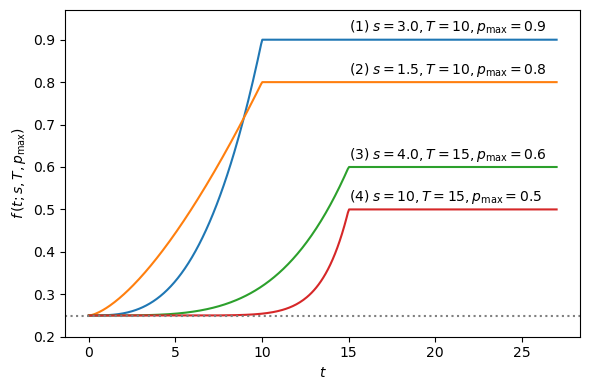

In [53]:
p0 = 0.25
params = [
    (3.0, 10, 0.9), 
    (1.5, 10, 0.8), 
    (4.0, 15, 0.6),
    (10, 15, 0.5), 
]

t = np.linspace(0, 27, 400)

plt.figure(figsize=(6, 4))
for i, (s, T, pmax) in enumerate(params):
    f = lambda t: np.where(t < T, p0 + (pmax - p0) * (t / T) ** s, pmax)
    plt.plot(t, f(t))
    plt.text(15, pmax+0.008, f"$({i+1})\\; s={s}, T={T}, p_{{\\max}}={pmax}$", ha='left', va='bottom')

plt.axhline(p0, ls=":", color="grey")
plt.xlabel("$t$")
plt.ylabel("$f\\,(t; s, T, p_{\\max})$")
plt.ylim(0.2, 0.97)
plt.tight_layout()
plt.savefig('./figures/ceiling_model_curves.png', dpi=300)


# Get data

In [3]:
data = get_data()
analysis_arrays = get_analysis_arrays(data)

# analysis_arrays = get_first_n_trials(
#     analysis_arrays,
#     n_trials=100
# )

word_order_partic = analysis_arrays['word_order_partic'] 
interpretation_fs_partic = analysis_arrays['interpretation_fs_partic'] 
scenes_trials = analysis_arrays['scenes_trials'] 
true_scenes_trials = analysis_arrays['true_scenes_trials'] 
signals = analysis_arrays['signals'] 
history_choices_indices = analysis_arrays['history_choices_indices']
orders = analysis_arrays['orders']

/mnt/c/Users/faust/OneDrive - UvA/research_projects/2022_joint_learning/model/scripts/data_functions.py:172: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(object_to_index_dict)
/mnt/c/Users/faust/OneDrive - UvA/research_projects/2022_joint_learning/model/scripts/data_functions.py:177: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(word_to_index_dict)
/mnt/c/Users/faust/OneDrive - UvA/research_projects/2022_joint_learning/model/scripts/data_functions.py:271: SettingWithCopyWarning: 
A value is trying to be set on a

In [4]:
right_answers = (history_choices_indices == 0).astype(int)

trial_index, participant_index = np.indices(
    history_choices_indices.shape
)

df = pd.DataFrame(
    data={
        'trial': trial_index.flatten(),
        'partic': participant_index.flatten(),
        # word orders
        'order': word_order_partic.values[
            participant_index.flatten()
        ],
        # signals,
        'correct': right_answers.flatten()
    }
)


In [5]:
df.partic.unique().shape

(325,)

# Calculate p-value of H that first trial accuracy =0.25

In [4]:
df_pvalue = df[df['trial']==0].groupby('order').agg(
    k=('correct', np.sum),
    N=('correct', 'count')
)

/tmp/ipykernel_25967/1770948749.py:1: FutureWarning: The provided callable <function sum at 0x7fa108372340> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  df_pvalue = df[df['trial']==0].groupby('order').agg(


In [5]:
df_pvalue = df_pvalue.reset_index()

In [6]:
df_pvalue

,order,k,N
0,osv,14,54
1,ovs,18,58
2,sov,8,51
3,svo,9,59
4,vos,12,49
5,vso,12,54


In [44]:
# Calculate two-tailed p-values for binomial test
# Using the binomial distribution with p=0.25 and N=60
def two_tailed_p(k, N, p):
    # Probability of the observed value
    observed_p = binom.pmf(k, N, p)
    # Get all pmf values
    pmfs = binom.pmf(np.arange(0, N + 1), N, p)
    # Two-tailed: sum of probabilities less than or equal to the observed
    p_val = pmfs[pmfs <= observed_p].sum()
    return p_val

In [51]:
# Recalculate two-tailed p-values using the updated Ns
df_pvalue['two_tailed_p'] = df_pvalue.apply(lambda row: binomtest(row['k'], row['N'], 0.25).pvalue, axis=1)
df_pvalue

,order,k,N,two_tailed_p
0,osv,14,54,0.875451
1,ovs,18,58,0.289935
2,sov,8,51,0.145931
3,svo,9,59,0.097578
4,vos,12,49,1.000000
5,vso,12,54,0.753867


# Model with learning cascade

$$
f(t;\,s,T)=
\begin{cases}
p_0 + \bigl(p_{\max}-p_0\bigr)\left(\dfrac{t}{T}\right)^{s}, & 0 \le t < T,\\[6pt]
p_{\max}, & t \ge T,
\end{cases}
\qquad s>1,\; T>0.
$$

In [33]:
# numeric participant and order codes
pid_codes,  pid_idx   = np.unique(df.partic.values, return_inverse=True)
ord_codes,  ord_idx_t = np.unique(df.order .values, return_inverse=True)
P  = pid_codes.size                       # participants
K  = ord_codes.size                       # order levels

# For the order main effect we need one code *per participant*
order_per_pid = np.zeros(P, dtype=int)
order_per_pid[np.arange(P)] = ord_idx_t[np.searchsorted(pid_idx, np.arange(P))]

# trial indices per row 
t        = df.trial.values.astype("float32")
pid_row  = pid_idx.astype("int32")
y_obs    = df.correct.values.astype("int8")

with pm.Model() as cascade:

    # hyper-priors (weakly informative) 

    # ---------- hyper-priors (weakly informative) --------------------------
    #           centre each link scale around 0 with broad SD = 1
    mu_log_s     = pm.Normal("mu_log_s",   0., 2.)
    mu_log_T     = pm.Normal("mu_log_T",   100, 50.)
    mu_logit_C   = pm.Normal("mu_logit_C", pm.math.logit(0.9), 0.3)

    # variation between participants within their word order
    sigma_log_s  = pm.HalfNormal("sigma_log_s", 2.)
    sigma_log_T  = pm.HalfNormal("sigma_log_T", 10.)
    sigma_logitC = pm.HalfNormal("sigma_logitC", 0.3)

    # variation of the word order effects around their mean,
    # with a sum-to-zero constraint
    # soft-centre them so the group mean is the intercept μ
    ord_s  = pm.Normal("ord_s",  0., 0.5, shape=K)
    ord_T  = pm.Normal("ord_T",  0., 20., shape=K)
    ord_C  = pm.Normal("ord_C",  0., 1., shape=K)
    ord_s  = ord_s  - pm.math.mean(ord_s)
    ord_T  = ord_T  - pm.math.mean(ord_T)
    ord_C  = ord_C  - pm.math.mean(ord_C)

    # participant-level values in unconstrained spaces
    log_s_i    = pm.Normal("log_s_i",
                           mu_log_s   + ord_s[order_per_pid],
                           sigma_log_s,
                           shape=P)
    log_T_i    = pm.Normal("log_T_i",
                           mu_log_T   + ord_T[order_per_pid],
                           sigma_log_T,
                           shape=P)
    logit_C_i  = pm.Normal("logit_C_i",
                           mu_logit_C + ord_C[order_per_pid],
                           sigma_logitC,
                           shape=P)

    # ---------- transform to the natural scales ----------------------------
    # enforce s_i>1 by adding 1 after the softplus
    s_i = pm.Deterministic("s_i", pm.math.log1pexp(log_s_i)+1)
    T_i = pm.Deterministic("T_i", pm.math.log1pexp(log_T_i))     # >0
    C_i = pm.Deterministic("C_i", pm.math.sigmoid(logit_C_i))    # in (0,1)

    # vectorised probability for every row 
    # gather participant parameters for each trial row
    s_row = s_i[pid_row]
    T_row = T_i[pid_row]
    C_row = C_i[pid_row]

    ratio  = t / T_row
    grow   = 0.25 + (C_row - 0.25) * ratio**s_row
    p_row  = pm.math.switch(t < T_row, grow, C_row)

    pm.Deterministic('p_row', p_row)

    # likelihood 
    y = pm.Bernoulli("y", p_row, observed=y_obs)

In [ ]:
with cascade:
    trace = pm.sample(
        draws       = 1000,
        tune        = 1000,
        # target_accept = 0.9,
        chains      = 4,
        cores       = 4,
        # init = "jitter+adapt_diag",
        # nuts_sampler='numpyro'
    )
    trace.to_netcdf('../results/cascademodel.cdf')

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_log_s, mu_log_T, mu_logit_C, sigma_log_s, sigma_log_T, sigma_logitC, ord_s, ord_T, ord_C, log_s_i, log_T_i, logit_C_i]


Output()

In [5]:
trace = az.from_netcdf('../results/cascademodel.cdf')

# Prior predictives

Sampling: [log_T_i, log_s_i, logit_C_i, mu_log_T, mu_log_s, mu_logit_C, ord_C, ord_T, ord_s, sigma_log_T, sigma_log_s, sigma_logitC, y]


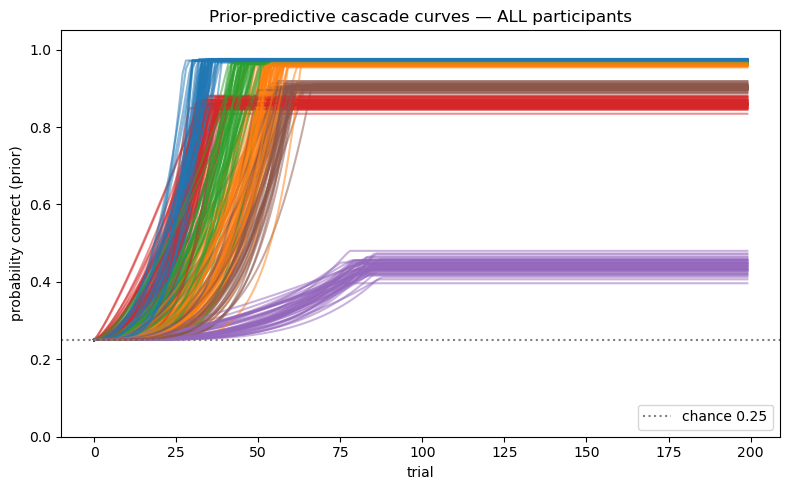

In [54]:
with cascade:
    prior_pred = pm.sample_prior_predictive(samples=1)

# shape (N_rows,)
p_sim = prior_pred.prior["p_row"].values.squeeze()

# t_row, pid_row are the same arrays built from df
t_row  = df.trial.values
# integer code per row
pid_row= pid_idx
P      = pid_codes.size

plt.figure(figsize=(8, 5))

# loop over participants
for pid in range(P):
    
    rows = pid_row == pid
    color = f"C{ord_idx_t[np.argwhere(rows).flatten()[0]]}"
    plt.plot(
        t_row[rows], 
        p_sim[rows], 
        alpha=.5, 
        color=color
    )

plt.axhline(0.25, color="grey", linestyle=":", label="chance 0.25")
plt.xlabel("trial")
plt.ylabel("probability correct (prior)")
plt.title("Prior-predictive cascade curves — ALL participants")
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.tight_layout()

# Analyse posterior

In [10]:
trace.posterior

<xarray.Dataset> Size: 2GB
Dimensions:         (chain: 4, draw: 1000, mu_log_s_dim_0: 6,
                     log_s_i_dim_0: 325, mu_T_dim_0: 6, mu_C_dim_0: 6,
                     T_i_dim_0: 325, C_i_dim_0: 325, s_i_dim_0: 325,
                     p_row_dim_0: 65000)
Coordinates:
  * chain           (chain) int64 32B 0 1 2 3
  * draw            (draw) int64 8kB 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
  * mu_log_s_dim_0  (mu_log_s_dim_0) int64 48B 0 1 2 3 4 5
  * log_s_i_dim_0   (log_s_i_dim_0) int64 3kB 0 1 2 3 4 ... 320 321 322 323 324
  * mu_T_dim_0      (mu_T_dim_0) int64 48B 0 1 2 3 4 5
  * mu_C_dim_0      (mu_C_dim_0) int64 48B 0 1 2 3 4 5
  * T_i_dim_0       (T_i_dim_0) int64 3kB 0 1 2 3 4 5 ... 320 321 322 323 324
  * C_i_dim_0       (C_i_dim_0) int64 3kB 0 1 2 3 4 5 ... 320 321 322 323 324
  * s_i_dim_0       (s_i_dim_0) int64 3kB 0 1 2 3 4 5 ... 320 321 322 323 324
  * p_row_dim_0     (p_row_dim_0) int64 520kB 0 1 2 3 ... 64997 64998 64999
Data variables:
    mu_log_s        (chain, draw, mu_log_s_dim_0) float64 192kB -0.6308 ... -...
    log_s_i         (chain, draw, log_s_i_dim_0) float64 10MB 3.247 ... 1.259
    mu_T            (chain, draw, mu_T_dim_0) float64 192kB 31.54 ... 2.593
    mu_C            (chain, draw, mu_C_dim_0) float64 192kB 0.7993 ... 0.9648
    sigma_log_s     (chain, draw) float64 32kB 3.479 3.427 3.524 ... 3.176 3.056
    sigma_T         (chain, draw) float64 32kB 68.65 66.45 73.9 ... 68.28 77.96
    sigma_C         (chain, draw) float64 32kB 0.2647 0.2786 ... 0.2695 0.2587
    T_i             (chain, draw, T_i_dim_0) float64 10MB 87.3 24.88 ... 119.2
    C_i             (chain, draw, C_i_dim_0) float64 10MB 0.5154 ... 0.9489
    s_i             (chain, draw, s_i_dim_0) float64 10MB 4.285 3.366 ... 2.509
    p_row           (chain, draw, p_row_dim_0) float64 2GB 0.25 0.25 ... 0.9489
Attributes:
    created_at:                 2025-08-28T00:04:36.447706+00:00
    arviz_version:              0.21.0
    inference_library:          pymc
    inference_library_version:  5.23.0
    sampling_time:              6933.069179534912
    tuning_steps:               1000

array([[<Axes: title={'center': 'mu_log_s'}>,
        <Axes: title={'center': 'mu_log_s'}>],
       [<Axes: title={'center': 'sigma_log_s'}>,
        <Axes: title={'center': 'sigma_log_s'}>],
       [<Axes: title={'center': 'mu_T'}>,
        <Axes: title={'center': 'mu_T'}>],
       [<Axes: title={'center': 'sigma_T'}>,
        <Axes: title={'center': 'sigma_T'}>],
       [<Axes: title={'center': 'mu_C'}>,
        <Axes: title={'center': 'mu_C'}>],
       [<Axes: title={'center': 'sigma_C'}>,
        <Axes: title={'center': 'sigma_C'}>]], dtype=object)

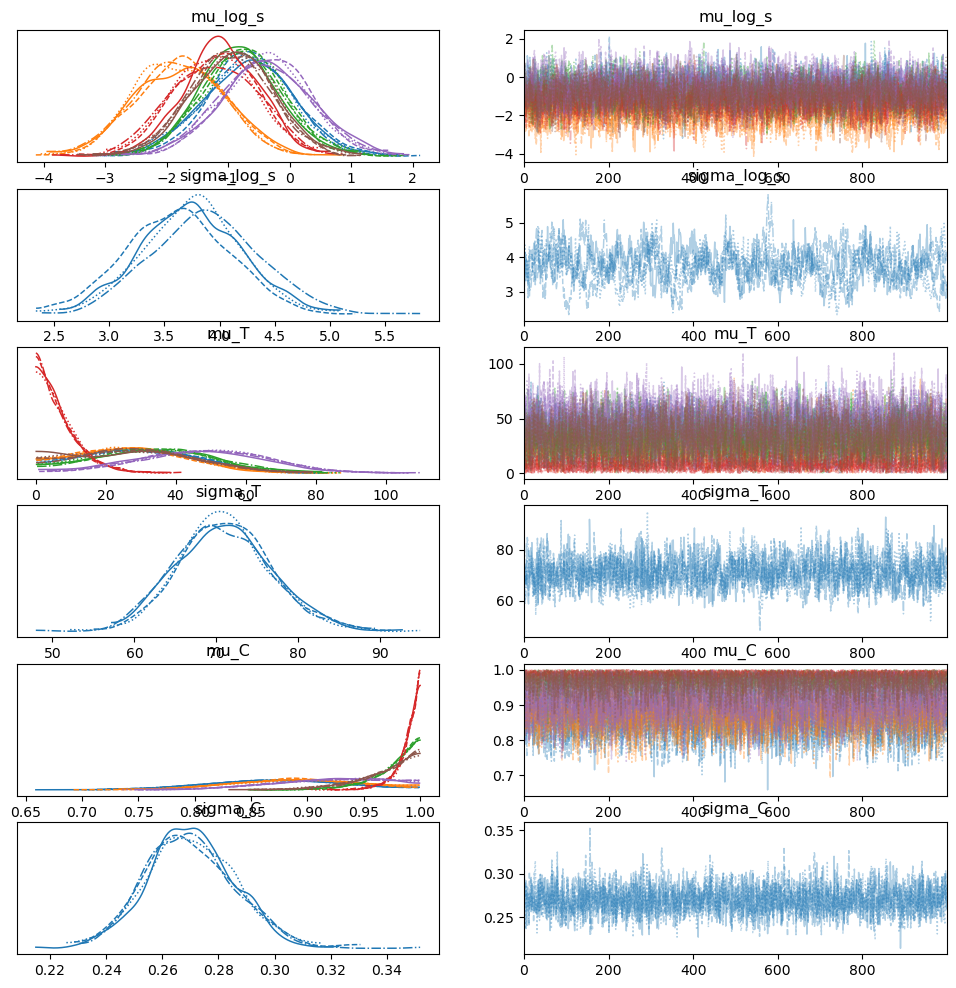

In [14]:
az.plot_trace(
    trace,
    ['mu_log_s', 'sigma_log_s', 'mu_T', 'sigma_T', 'mu_C', 'sigma_C']
)

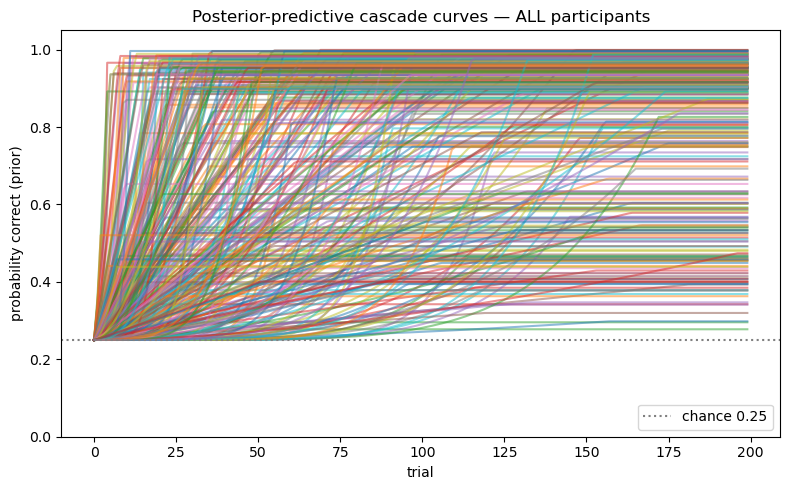

In [15]:
p_sim = trace.posterior["p_row"].values.squeeze()[0,500]     # shape (N_rows,)

# t_row, pid_row are the same arrays you built from df
t_row  = df.trial.values
pid_row= pid_idx                      # integer code per row
P      = pid_codes.size

plt.figure(figsize=(8, 5))

for pid in range(P):
    rows = pid_row == pid
    plt.plot(t_row[rows], p_sim[rows], alpha=.5)

plt.axhline(0.25, color="grey", linestyle=":", label="chance 0.25")
plt.xlabel("trial")
plt.ylabel("probability correct (prior)")
plt.title("Posterior-predictive cascade curves — ALL participants")
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.tight_layout()

# Posterior ranking

In [17]:

# ------------------------------------------------------------
# 1.  Collapse the posterior to (samples , K)
# ------------------------------------------------------------
C_post = trace.posterior["mu_C"]                     # dims: (chain, draw, K)
labels  = list(ord_codes)                             # e.g. ['SVO','SOV',...]

C_arr = C_post.stack(sample=("chain", "draw")).values   # shape (K , S) or (S , K)
if C_arr.shape[0] == len(labels):                      # make sure rows = samples
    C_arr = C_arr.T                                    # -> (S , K)
S, K = C_arr.shape

# ------------------------------------------------------------
# 2.  Convert each sample to a ranking tuple
#     higher C ⇒ earlier in the tuple
# ------------------------------------------------------------
def ranking(row):
    return tuple(np.array(labels)[row.argsort()[::-1]])   # descending

rankings = [ranking(row) for row in C_arr]                # list of S tuples

# ------------------------------------------------------------
# 3.  Count and normalise
# ------------------------------------------------------------
rank_series = pd.Series(rankings, dtype="object")
rank_probs  = (rank_series.value_counts() / S).rename("prob")

# ------------------------------------------------------------
# 4.  Display the top‑N most probable rankings
# ------------------------------------------------------------
N = 10
print(f"\nTop {N} complete rankings of word orders by C (posterior):\n")
display(rank_probs.head(N).to_frame())

# …and, if you want the full distribution, keep `rank_probs`
# rank_probs.to_csv("ranking_posterior_C.csv")


Top 10 complete rankings of word orders by C (posterior):



,prob
"(svo, sov, vso, vos, ovs, osv)",0.06450
"(svo, vso, sov, vos, ovs, osv)",0.04050
"(svo, sov, vso, vos, osv, ovs)",0.03975
"(svo, sov, vso, ovs, vos, osv)",0.03625
"(sov, svo, vso, vos, ovs, osv)",0.03450
"(svo, vso, sov, vos, osv, ovs)",0.03400
"(vso, svo, sov, vos, ovs, osv)",0.02450
"(svo, vso, sov, ovs, vos, osv)",0.02400
"(sov, svo, vso, vos, osv, ovs)",0.02350
"(svo, sov, vso, ovs, osv, vos)",0.02350


# Learning curves of individual participants

In [18]:
# ---- get p_row draws as (samples, N_rows) -------------------------
# stack chain & draw into one axis for convenience
p_samples = trace.posterior["p_row"].stack(sample=("chain", "draw")).values  # shape (N_rows, n_samples)
p_samples = np.swapaxes(p_samples, 0, 1)  # -> (n_samples, N_rows)

# ---- basic info from the original dataframe ----------------------
if "partic" not in df.columns or "trial" not in df.columns:
    raise RuntimeError("The dataframe `df` must contain 'partic' and 'trial' columns.")

# re‑index participants 0…P‑1 if not done yet
pid_codes, pid_row = np.unique(df["partic"].values, return_inverse=True)
P = len(pid_codes)

# Convenience: bring trial & correct into arrays aligned with p_row
trial_row   = df["trial"].values
correct_row = df["correct"].values

# -------------------------------------------------------------------
# Create one PNG plot per participant in /mnt/data/
# -------------------------------------------------------------------
for pid in range(P):
    mask = pid_row == pid               # rows for this participant
    if mask.sum() == 0:
        continue

    trials = trial_row[mask]
    order  = np.argsort(trials)
    trials = trials[order]

    # slice & sort posterior samples correspondingly
    p_part = p_samples[:, mask][:, order]   # (samples, n_trials)
    mean   = p_part.mean(axis=0)
    hdi_lo = np.percentile(p_part, 2.5, axis=0)
    hdi_hi = np.percentile(p_part, 97.5, axis=0)

    # ---- plot -----------------------------------------------------
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.fill_between(trials, hdi_lo, hdi_hi, color="tab:blue", alpha=0.25,
                    label="95% HDI")
    ax.plot(trials, mean, color="tab:blue", lw=2, label="posterior mean")

    # overlay raw data (jitter vertically for visibility)
    ax.scatter(trials, correct_row[mask][order] + np.random.uniform(-0.02, 0.02, size=trials.size),
               s=12, color="black", alpha=0.4, label="observed")

    ax.axhline(0.25, color="grey", ls="--", lw=0.8, label="chance (.25)")
    ax.set(xlabel="trial", ylabel="accuracy",
           ylim=(-0.05, 1.05),
           title=f"Participant {pid_codes[pid]} – posterior accuracy curve")
    ax.legend(loc="lower right", fontsize=8)
    plt.tight_layout()

    # ---- save -----------------------------------------------------
    fname = f"participant_{pid_codes[pid]}_accuracy_curve.png"
    fig.savefig(fname, dpi=120)
    plt.close(fig)

print(f"✅ Generated {P} curve images to /mnt/data/")

✅ Generated 325 curve images to /mnt/data/


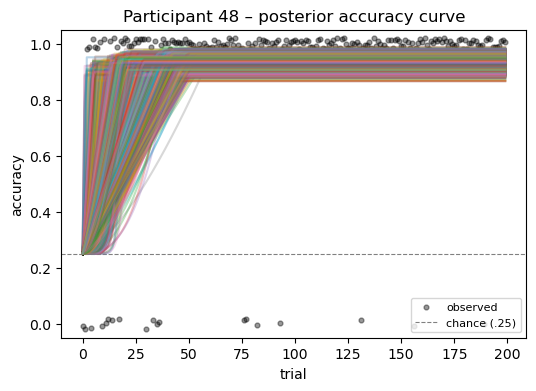

In [22]:
# rows for this participant
participant_index = 48
mask = pid_row == participant_index

fig, ax = plt.subplots(figsize=(6, 4))

trials = trial_row[mask]
order  = np.argsort(trials)
trials = trials[order]

# overlay raw data (jitter vertically for visibility)
ax.scatter(trials, correct_row[mask][order] + np.random.uniform(-0.02, 0.02, size=trials.size),
           s=12, color="black", alpha=0.4, label="observed")

ax.axhline(0.25, color="grey", ls="--", lw=0.8, label="chance (.25)")
ax.set(xlabel="trial", ylabel="accuracy",
       ylim=(-0.05, 1.05),
       title=f"Participant {pid_codes[48]} – posterior accuracy curve")
ax.legend(loc="lower right", fontsize=8)

# slice & sort posterior samples correspondingly
p_part = p_samples[:, mask][:, order]   # (samples, n_trials)

for y in p_part:
    ax.plot(np.arange(len(y)), y, alpha=0.3)

fig.savefig('explicit_example.png', dpi=300)

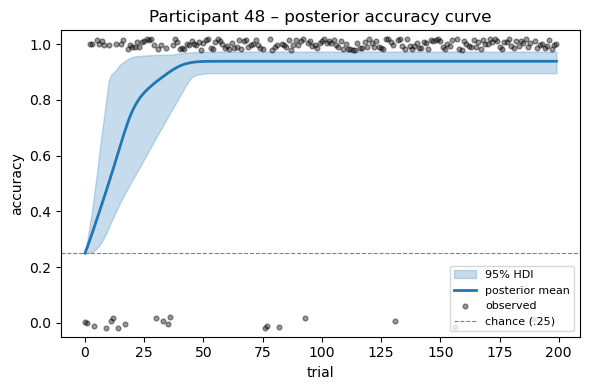

In [25]:
mean   = p_part.mean(axis=0)
hdi_lo = np.percentile(p_part, 2.5, axis=0)
hdi_hi = np.percentile(p_part, 97.5, axis=0)

fig, ax = plt.subplots(figsize=(6, 4))
ax.fill_between(trials, hdi_lo, hdi_hi, color="tab:blue", alpha=0.25,
                label="95% HDI")
ax.plot(trials, mean, color="tab:blue", lw=2, label="posterior mean")

# overlay raw data (jitter vertically for visibility)
ax.scatter(trials, correct_row[mask][order] + np.random.uniform(-0.02, 0.02, size=trials.size),
           s=12, color="black", alpha=0.4, label="observed")

ax.axhline(0.25, color="grey", ls="--", lw=0.8, label="chance (.25)")
ax.set(xlabel="trial", ylabel="accuracy",
       ylim=(-0.05, 1.05),
       title=f"Participant {pid_codes[participant_index]} – posterior accuracy curve")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()

# Pairwise comparisons of word orders

In [27]:
def pairwise_prob_greater(posterior_da: xr.DataArray,
                          labels: list[str]) -> pd.DataFrame:
    """
    posterior_da : xarray with dims (chain, draw, K)
    labels       : list of length K with the order names
    Returns a K×K DataFrame whose (i,j) entry is
        P( θ_i > θ_j | data )
    """
    # collapse chain & draw into one axis -> ndarray (A, B)
    a = posterior_da.stack(sample=("chain", "draw")).values          

    # ensure shape is (K, N_samples)
    K = len(labels)
    if a.shape[0] != K:          # orientation came out as (N_samples, K)
        a = a.T                  #      -->  transpose to (K, N_samples)

    # broadcast comparison across samples: (K,1,N) > (1,K,N)
    probs = (a[:, None, :] > a[None, :, :]).mean(axis=2)   # (K, K)

    return pd.DataFrame(probs, index=labels, columns=labels)



def style_extremes_lower_triangle(df: pd.DataFrame, cutoff=0.95, fmt="{:.3f}"):
    """
    Return a Styler that:
    - colors cells red if |p - 0.5| > cutoff - 0.5,
    - hides the upper triangle (including the diagonal) by making them blank.
    """
    def highlight(val):
        if pd.isna(val):
            return ""
        if (val > cutoff) or (val < 1 - cutoff):
            return "background-color:#ffcccc"
        return ""

    # Mask upper triangle including diagonal
    mask = np.triu(np.ones(df.shape), k=0).astype(bool)
    df_masked = df.mask(mask)

    # Custom formatter to suppress 'nan' display
    def safe_format(val):
        if pd.isna(val):
            return ""
        return fmt.format(val)

    return df_masked.style.applymap(highlight).format(safe_format)


# -----------------------------------------------------------------
# build the three tables
# -----------------------------------------------------------------
order_labels = list(ord_codes)   # e.g. ['SVO','SOV', ...]

prob_ord_s = pairwise_prob_greater(trace.posterior['mu_log_s'], order_labels)
prob_ord_T = pairwise_prob_greater(trace.posterior['mu_T'], order_labels)
prob_ord_C = pairwise_prob_greater(trace.posterior['mu_C'], order_labels)

print("\nP( ord_s[row] > ord_s[col] )  – faster / steeper cascade\n")
display(style_extremes_lower_triangle(prob_ord_s))

print("\nP( ord_T[row] > ord_T[col] )  – later plateau "
      "(smaller means faster to ceiling)\n")
display(style_extremes_lower_triangle(prob_ord_T))

print("\nP( ord_C[row] > ord_C[col] )  – higher asymptotic accuracy\n")
display(style_extremes_lower_triangle(prob_ord_C))


P( ord_s[row] > ord_s[col] )  – faster / steeper cascade



/tmp/ipykernel_16223/4082483493.py:47: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  return df_masked.style.applymap(highlight).format(safe_format)


,osv,ovs,sov,svo,vos,vso
osv,,,,,,
ovs,0.137,,,,,
sov,0.447,0.852,,,,
svo,0.288,0.724,0.333,,,
vos,0.601,0.916,0.653,0.792,,
vso,0.388,0.798,0.432,0.602,0.282,



P( ord_T[row] > ord_T[col] )  – later plateau (smaller means faster to ceiling)



/tmp/ipykernel_16223/4082483493.py:47: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  return df_masked.style.applymap(highlight).format(safe_format)


,osv,ovs,sov,svo,vos,vso
osv,,,,,,
ovs,0.457,,,,,
sov,0.561,0.614,,,,
svo,0.085,0.092,0.060,,,
vos,0.792,0.812,0.733,0.987,,
vso,0.476,0.519,0.413,0.890,0.213,



P( ord_C[row] > ord_C[col] )  – higher asymptotic accuracy



/tmp/ipykernel_16223/4082483493.py:47: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  return df_masked.style.applymap(highlight).format(safe_format)


,osv,ovs,sov,svo,vos,vso
osv,,,,,,
ovs,0.596,,,,,
sov,0.955,0.938,,,,
svo,0.984,0.974,0.693,,,
vos,0.731,0.661,0.142,0.067,,
vso,0.936,0.897,0.408,0.248,0.800,


# Posterior predictive checks

In [37]:
with cascade:
    post_pred = pm.sample_posterior_predictive(
        trace,  # InferenceData
        var_names=["y"],
        random_seed=42
    )

Sampling: [y]


Output()

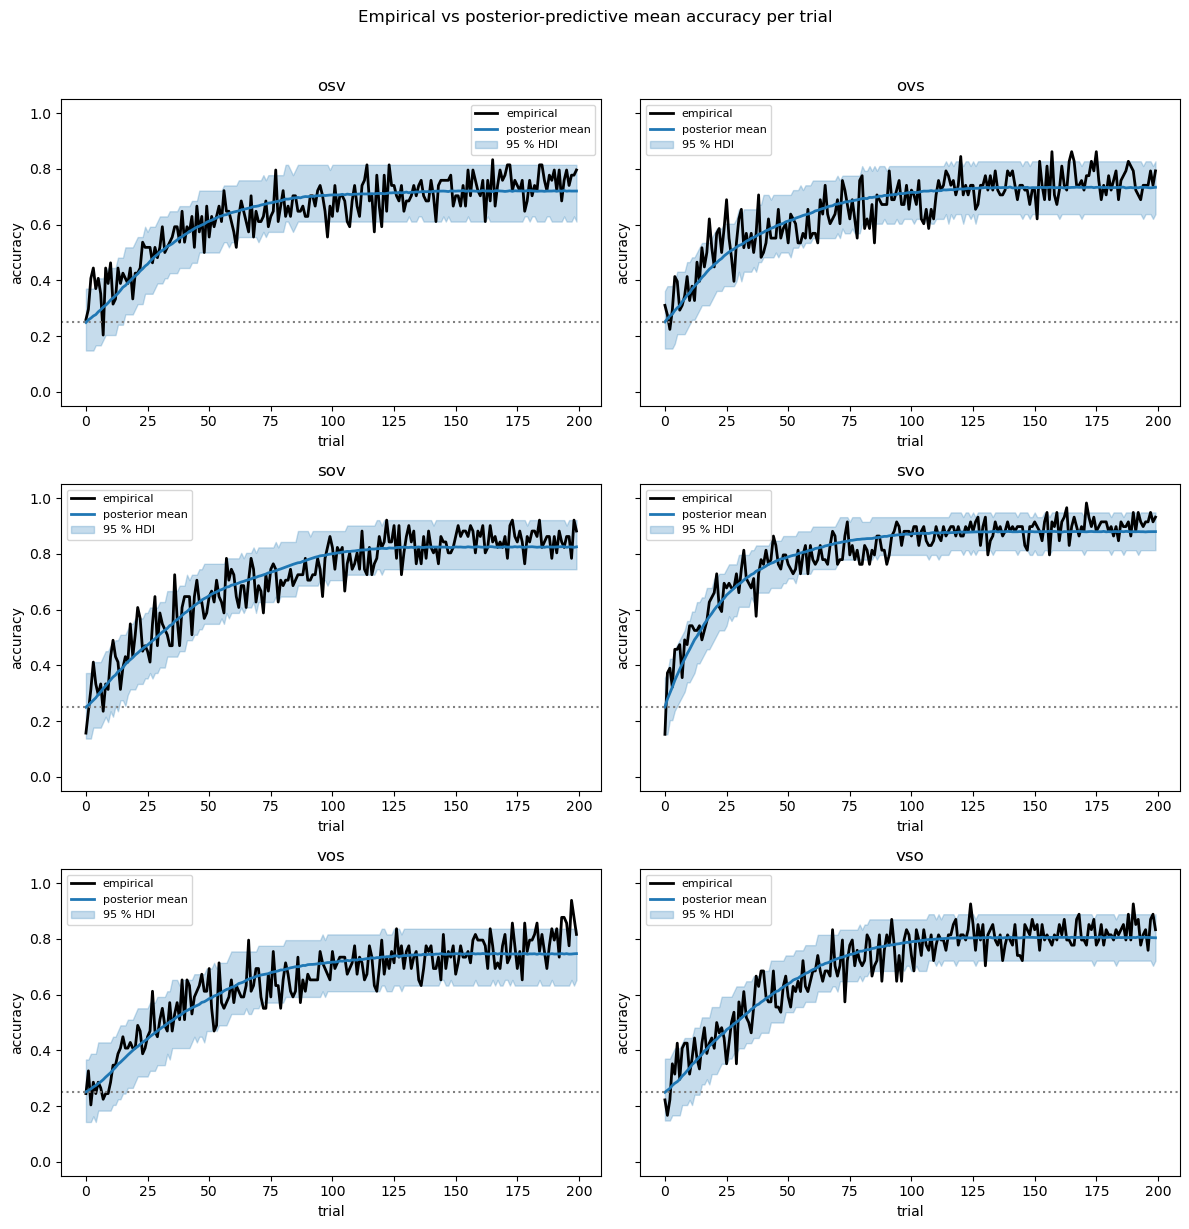

In [38]:
# xarray → NumPy   shape: (chains , draws , rows)
y_pp_arr = post_pred.posterior_predictive["y"].values

chains, draws, N_rows = y_pp_arr.shape
# total samples
S = chains * draws

# reshape to (rows , samples)
y_pp_samples = y_pp_arr.reshape(chains * draws, N_rows).T

# Quick references from the original DF
orders_arr  = df["order"].values
trials_arr  = df["trial"].values
correct_arr = df["correct"].values

# e.g. ['SVO','SOV',...]
order_levels = list(ord_codes)

# Compute empirical & posterior-predictive means
records = []
for ord_label in order_levels:
    rows_ord = orders_arr == ord_label
    for t in np.unique(trials_arr[rows_ord]):
        rows = rows_ord & (trials_arr == t)
        idx  = np.where(rows)[0]

        emp_mean = correct_arr[idx].mean()

        # posterior predictive: mean over those rows, for every sample
        sample_means = y_pp_samples[idx].mean(axis=0)   # shape (S,)
        post_mean = sample_means.mean()
        hdi_low, hdi_high = az.hdi(sample_means, hdi_prob=0.95)

        records.append(dict(order=ord_label, trial=t,
                            emp=emp_mean,
                            post=post_mean,
                            lo=hdi_low, hi=hdi_high))

df_plot = pd.DataFrame(records).sort_values(["order", "trial"])

n_col = 2
n_row = int(np.ceil(len(order_levels) / n_col))
fig, axes = plt.subplots(n_row, n_col, figsize=(12, 4 * n_row), sharey=True)

for ax, ord_label in zip(axes.flat, order_levels):
    sub = df_plot.query("order == @ord_label")
    ax.plot(sub.trial, sub.emp,  c="black", lw=2, label="empirical")
    ax.plot(sub.trial, sub.post, c="tab:blue", lw=2, label="posterior mean")
    ax.fill_between(sub.trial, sub.lo, sub.hi, color="tab:blue", alpha=0.25,
                    label="95 % HDI")
    ax.axhline(0.25, ls=":", c="grey")
    ax.set(title=f"{ord_label}", xlabel="trial", ylabel="accuracy", ylim=(-0.05, 1.05))
    ax.legend(fontsize=8)

# remove empty panels if K is odd
for ax in axes.flat[len(order_levels):]:
    fig.delaxes(ax)

fig.suptitle("Empirical vs posterior-predictive mean accuracy per trial", y=1.02)
plt.tight_layout()
plt.savefig('./empirical_vs_posteriorpred.png', dpi=300)

# Bambi model

In [6]:
def logit(p):
   p = np.clip(p, 1e-15, 1 - 1e-15) # Clip to avoid log(0) and log(negative) errors
   return np.log(p / (1 - p))

In [8]:
bmb_df = df.copy(deep=True)

bmb_df.loc[:, 'scaled_trial'] = bmb_df.trial / bmb_df.trial.max()

bmb_df["offset_intercept"] = logit(0.25)

model = bmb.Model(
     "correct ~ 0 + np.sqrt(trial):order + offset(offset_intercept) + (1|partic)",
    family='bernoulli',
    link='logit',
    categorical=['order', 'partic'],
    data=bmb_df
)

In [9]:
model.build()

In [10]:
model

       Formula: correct ~ 0 + np.sqrt(trial):order + offset(offset_intercept) + (1|partic)
        Family: bernoulli
          Link: p = logit
  Observations: 65000
        Priors: 
    target = p
        Common-level effects
            np.sqrt(trial):order ~ Normal(mu: [0. 0. 0. 0. 0. 0.], sigma: [0.2975 0.2975 0.2975 0.2975
                0.2975 0.2975])
        
        
        Group-level effects
            1|partic ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 2.749))
        
        Offset effects
            offset(offset_intercept) ~ 1

Run this to generate the file:

```{python}
trace_bmb = model.fit(idata_kwargs={"log_likelihood": True})
trace_bmb.to_netcdf('../results/logisticregression.cdf')
```

In [11]:
trace_bmb = az.from_netcdf('../results/logisticregression.cdf')

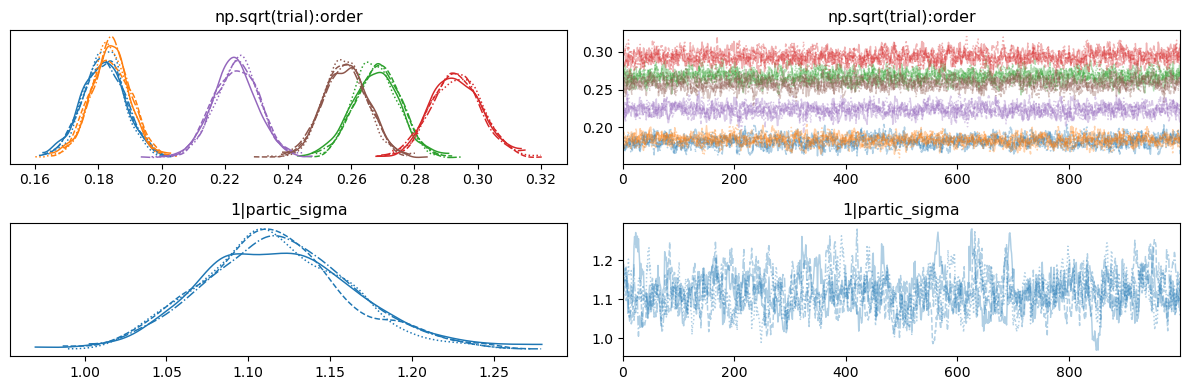

In [12]:
az.plot_trace(trace_bmb, var_names="~1|partic")
plt.tight_layout()

In [14]:
az.summary(trace_bmb, var_names=["np.sqrt(trial):order"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
np.sqrt(trial):order[osv],0.182,0.007,0.169,0.195,0.0,0.0,650.0,1347.0,1.0
np.sqrt(trial):order[ovs],0.184,0.006,0.172,0.195,0.0,0.0,893.0,1429.0,1.0
np.sqrt(trial):order[sov],0.268,0.007,0.254,0.281,0.0,0.0,863.0,1499.0,1.0
np.sqrt(trial):order[svo],0.293,0.008,0.279,0.309,0.0,0.0,907.0,1729.0,1.0
np.sqrt(trial):order[vos],0.224,0.007,0.209,0.236,0.0,0.0,938.0,1659.0,1.0
np.sqrt(trial):order[vso],0.258,0.007,0.245,0.271,0.0,0.0,816.0,1570.0,1.0


In [32]:
model

       Formula: correct ~ 0 + np.sqrt(trial):order_id + offset(offset_intercept) + (1|partic)
        Family: bernoulli
          Link: p = logit
  Observations: 65000
        Priors: 
    target = p
        Common-level effects
            np.sqrt(trial):order_id ~ Normal(mu: 0.0, sigma: 0.0537)
        
        Group-level effects
            1|partic ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 2.7826))
        
        Offset effects
            offset(offset_intercept) ~ 1
------
* To see a plot of the priors call the .plot_priors() method.
* To see a summary or plot of the posterior pass the object returned by .fit() to az.summary() or az.plot_trace()

/home/fausto/mambaforge/envs/pymc523/lib/python3.13/site-packages/arviz/rcparams.py:368: FutureWarning: stats.hdi_prob is deprecated since 0.18.0, use stats.ci_prob instead
  warnings.warn(
Default computed for unspecified variable: offset_intercept, partic


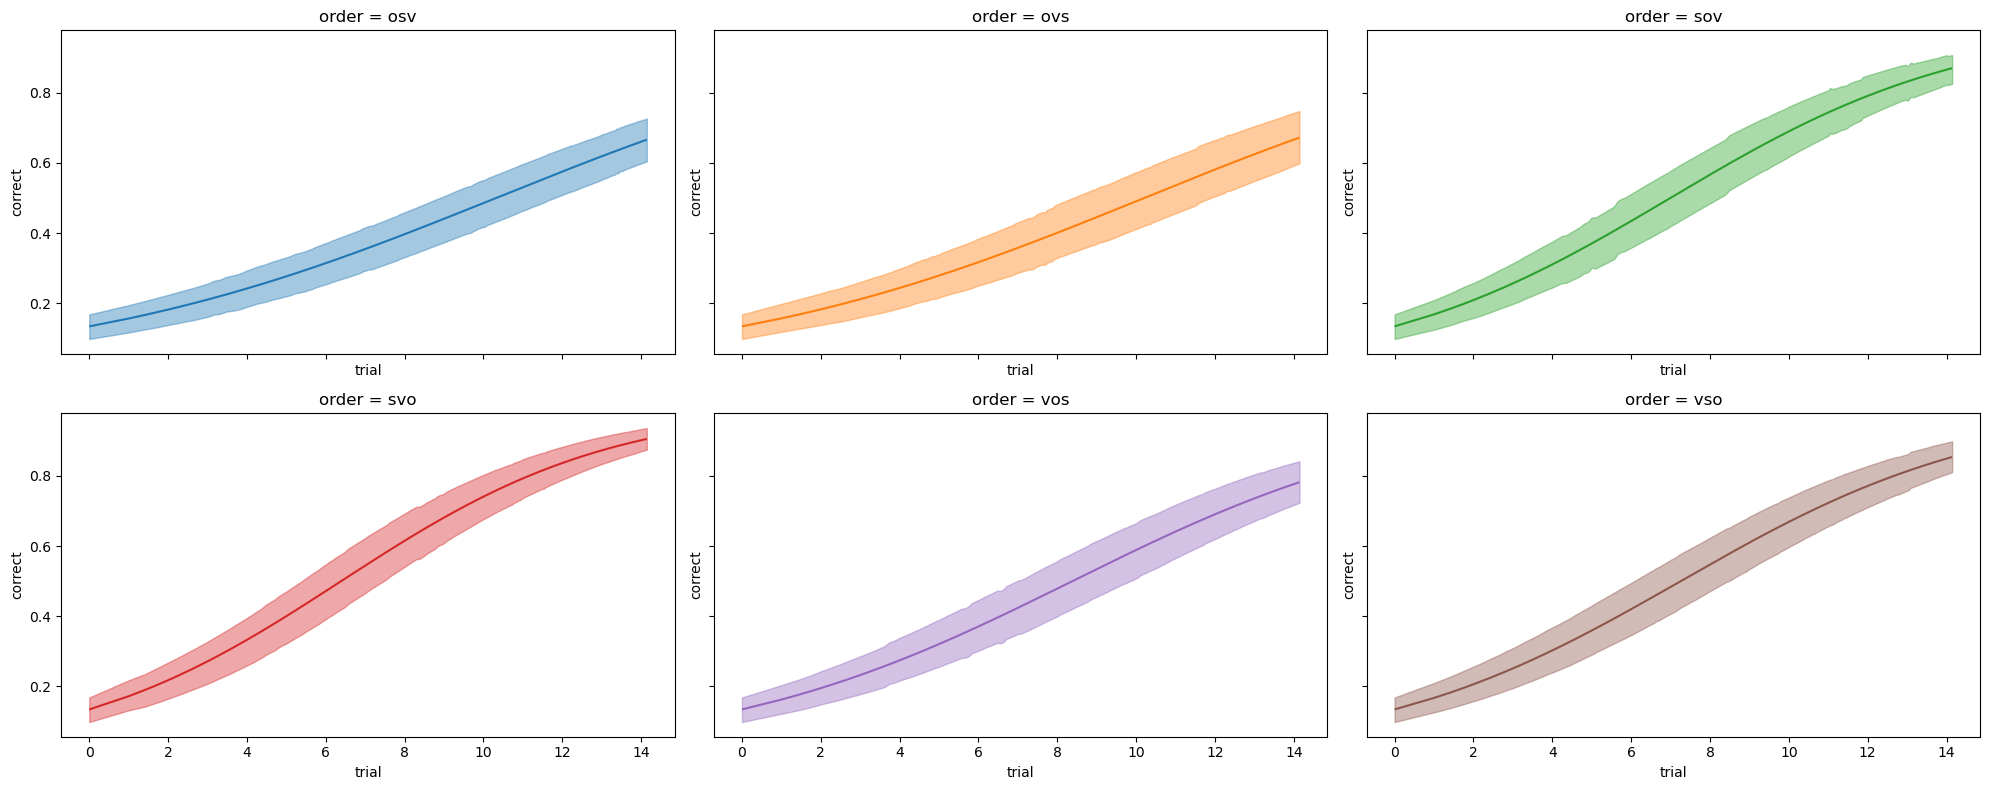

In [40]:
trial_vals   = np.arange(0, 201)                           # 0 … 200
order_levels = model.data["order"].cat.categories

fig, ax = bmb.interpret.plot_predictions(
    model,
    trace_bmb,                         # your InferenceData trace
    conditional={
        "trial": trial_vals,                                # x‑axis
        "order": order_levels,                           # colour
        # "offset_intercept": [logit(0.25)],          # logit(0.25)
    },
    transforms={"trial": np.sqrt},     # feed √trial to the model
    subplot_kwargs={"main": "trial", "group": "order", "panel": "order"},
    use_hdi=True,
    legend=False,
    fig_kwargs={"figsize": (20, 8), "sharey": True, "sharex": True},
)

# # 1 – place ticks at the √‑positions …
# raw_ticks = np.arange(0, 201, 50)          # 0, 50, 100, 150, 200
# ax[0,0].set_xticks(np.sqrt(raw_ticks))
# # 2 – … but label them with the raw numbers
# ax[0,0].set_xticklabels(raw_ticks)
# ax[0,0].set_xlim(0, np.sqrt(200))

# ax.set_xlabel("Trial number (0–200)")
# ax.set_ylabel("P(correct)")
# ax.set_title("Predicted accuracy over trials by word order");
plt.tight_layout()


In [25]:
print(ord_codes)

['osv' 'ovs' 'sov' 'svo' 'vos' 'vso']


In [17]:
idata_thin

<xarray.Dataset> Size: 272kB
Dimensions:                   (np.sqrt(trial):order_dim: 6, sample: 100,
                               partic__factor_dim: 325)
Coordinates:
  * np.sqrt(trial):order_dim  (np.sqrt(trial):order_dim) <U3 72B 'osv' ... 'vso'
  * partic__factor_dim        (partic__factor_dim) <U3 4kB '0' '1' ... '324'
  * sample                    (sample) object 800B MultiIndex
  * chain                     (sample) int64 800B 3 3 3 0 1 2 1 ... 3 1 1 1 0 3
  * draw                      (sample) int64 800B 288 840 237 50 ... 672 394 635
Data variables:
    np.sqrt(trial):order      (np.sqrt(trial):order_dim, sample) float64 5kB ...
    1|partic_sigma            (sample) float64 800B 1.156 1.171 ... 1.122 1.149
    1|partic                  (partic__factor_dim, sample) float64 260kB -0.8...
Attributes:
    created_at:                  2025-06-12T18:23:35.582329+00:00
    arviz_version:               0.21.0
    inference_library:           pymc
    inference_library_version:   5.23.0
    sampling_time:               173.6335690021515
    tuning_steps:                1000
    modeling_interface:          bambi
    modeling_interface_version:  0.15.0

In [19]:
idata_thin

<xarray.Dataset> Size: 272kB
Dimensions:                   (np.sqrt(trial):order_dim: 6, sample: 100,
                               partic__factor_dim: 325)
Coordinates:
  * np.sqrt(trial):order_dim  (np.sqrt(trial):order_dim) <U3 72B 'osv' ... 'vso'
  * partic__factor_dim        (partic__factor_dim) <U3 4kB '0' '1' ... '324'
  * sample                    (sample) object 800B MultiIndex
  * chain                     (sample) int64 800B 2 1 0 3 1 2 3 ... 0 3 2 3 1 1
  * draw                      (sample) int64 800B 578 504 447 472 ... 78 281 202
Data variables:
    np.sqrt(trial):order      (np.sqrt(trial):order_dim, sample) float64 5kB ...
    1|partic_sigma            (sample) float64 800B 1.061 1.032 ... 1.081 1.103
    1|partic                  (partic__factor_dim, sample) float64 260kB -0.9...
Attributes:
    created_at:                  2025-06-12T18:23:35.582329+00:00
    arviz_version:               0.21.0
    inference_library:           pymc
    inference_library_version:   5.23.0
    sampling_time:               173.6335690021515
    tuning_steps:                1000
    modeling_interface:          bambi
    modeling_interface_version:  0.15.0

In [57]:
thin_every = 5                      # keep every 20‑th draw  → 2000/20 ≈ 100 draws
idata_thin = trace_bmb.sel(draw=slice(None, None, thin_every))   # preserves 'chain'!

In [59]:
pred_draws = model.predict(
    idata=idata_thin,
    data=grid,
    include_group_specific=False,     # <- no (1|partic) random effects
    kind="response_params",         # replaces kind="mean"
    inplace=False,
)   # shape: (n_draws, n_grid_rows)

In [60]:
# 1.  The DataArray with shape (chain, draw, obs)
p_da = pred_draws.posterior["p"]          # <ArviZ DataArray>

# 2.  Stack chain+draw into a single axis called "sample"
p_stack = p_da.stack(sample=("chain", "draw"))

# 3.  Summary stats across all posterior samples
grid["mean"]  = p_stack.mean("sample").values
grid["lower"] = p_stack.quantile(0.025, dim="sample").values
grid["upper"] = p_stack.quantile(0.975, dim="sample").values

In [61]:
summ = az.summary(pred_draws, var_names=["p"], hdi_prob=0.95)
grid["mean"]  = summ["mean"].values
grid["lower"] = summ["hdi_2.5%"].values
grid["upper"] = summ["hdi_97.5%"].values

/home/fausto/mambaforge/envs/pymc523/lib/python3.13/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/home/fausto/mambaforge/envs/pymc523/lib/python3.13/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


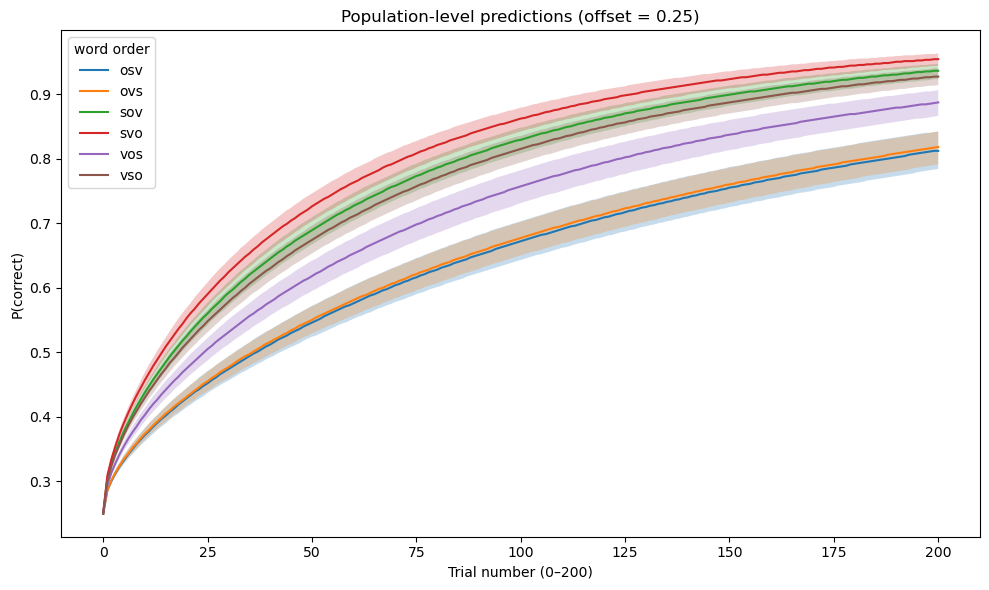

In [62]:
plt.figure(figsize=(10, 6))
for order in order_levels:
    sub = grid[grid["order"] == order]
    plt.plot(sub["trial"], sub["mean"], label=order)
    plt.fill_between(sub["trial"], sub["lower"], sub["upper"], alpha=0.25)

plt.xlabel("Trial number (0–200)")
plt.ylabel("P(correct)")
plt.title("Population‑level predictions (offset = 0.25)")
plt.legend(title="word order")
plt.tight_layout()
plt.show()

# Model comparison

In [43]:
waic_bmb = pm.waic(idata_thin)

In [44]:
waic_bmb

Computed from 200 posterior samples and 65000 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -31067.17   132.00
p_waic      309.67        -

In [45]:
with cascade:
    pm.compute_log_likelihood(trace)

Output()

In [46]:
waic_cascade = az.waic(trace)

/home/fausto/mambaforge/envs/pymc523/lib/python3.13/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


In [47]:
waic_cascade

Computed from 4000 posterior samples and 65000 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -29501.53   136.67
p_waic      761.59        -

There has been a warning during the calculation. Please check the results.

In [48]:
df_comp = az.compare({"logistic": waic_bmb, "cascade": waic_cascade}, ic='waic')

In [49]:
df_comp

,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
cascade,0,-29501.533528,761.585942,0.000000,0.875596,136.666722,0.000000,True,log
logistic,1,-31067.174764,309.670720,1565.641236,0.124404,132.003678,64.832955,False,log


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_waic (log)', ylabel='ranked models'>

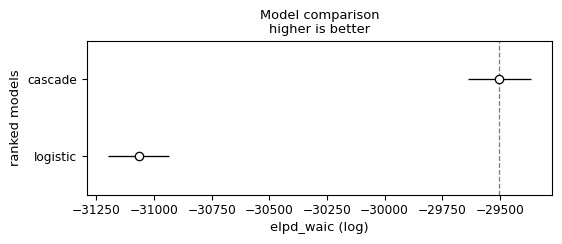

In [50]:
az.plot_compare(df_comp)